# 21h — Series 21: **sigma_ref FIX** — score denominator = the experiment's own sigma_prop + 17h path view

**Series 21 (supervised). Single arm. ONE change vs 21g:** the μ REINFORCE **score denominator**.

    OLD (21g):  score_j = (n_j - mu) / SIGMA_REF**2      SIGMA_REF = 10 (fixed, arbitrary)
    NEW (21h):  score_j = (n_j - mu) / sigma_prop**2      sigma_prop = the experiment's own count scatter

`sigma_prop` (2.576 … 40.975 MHz-equivalent counts) is the per-experiment photon-count noise already used
by the simulator (`n_j = mu + sigma_prop * eps_j`) and by the Fisher. So this makes the μ score the
*correct* REINFORCE score for `n ~ N(mu, sigma_prop^2)` and makes the update consistent with the error bar.
Everything else IDENTICAL to 21g/21f/21a: reward still the SUM log-likelihood `r_j = sum_i log W_ij`,
LR_MU=15 (linear decay), LR_GAMMA=0.5, CLIP=10, N_RUNS=100, N_ITER=30, init 0.5x truth.

**Prediction (falsifiable).** The only effect is a per-experiment rescale of the μ step by `100/sigma_prop^2`:
high-T cells (sigma_prop > 10, so the new denominator is bigger) get *smaller* steps ⇒ less overshoot;
low-T cells (sigma_prop < 10) get *larger* steps ⇒ more. Direction unchanged (reward unchanged); gamma
untouched (pathwise).

i.e. the per-run log-likelihood of the real data (averaged over the real scans). No `responsibility`
control, no `corr`, no z-scoring — **only this reward**. Everything else is 21a/17g frozen:
`SIGMA_REF=10`, z-form γ-score, `LR_MU=15` linear decay, `LR_GAMMA=0.5` annealed, `CLIP=10`,
`LAMBDA_MEAN=0`, `H_S_MIN=0.05`, `SEED=42`, init `0.5×truth`, `N_RUNS=100`, `N_ITER=30`, real targets.

## What this notebook is for
A close **visual inspection** of Anuar's reward dynamics:
1. **17h-style phase-space paths** `(μ, γ)` — 2 cols (1nW | 3nW) × 7 rows (T05…T100), blue path, black
   dots every 10 steps, green `o` = start, red `*` = end, truth dashed.
2. **Gradient values per step** — raw pre-clip `|grad_mu|`, clipped `|grad_mu|`, `|grad_gamma|`.
3. **Recovery-ratio figure with Fisher whiskers** — `ŷ/true` (μ & γ as hue), 2 stacked panels
   (1nW top, 3nW bottom), shared x = transmission; whiskers = `σ/y_true`.

Known context: in 21e this raw reward ran away and saturated `CLIP=10` (μ_hat pinned at the 200 bound).
Here we look at it directly to see *why* — the paths and the per-step gradients show it.


## Panel
- **FIG 1** 17h-style `(μ,γ)` phase-space paths (start / step-10 dots / end / truth).
- **FIG 2** per-step gradients: raw `|grad_mu|`, clipped `|grad_mu|`, `|grad_gamma|` (mean ± range per power).
- **FIG 3 ★** recovery ratio `ŷ/true` with Fisher whiskers (μ & γ hue; 1nW top, 3nW bottom; x = transmission).
- **TABLE** final values + MSE/STE.

Convention: figures render **inline only** (no savefig); the notebook is executed **in place**.


In [1]:
import math, time, os, sys
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float32)

for _p in [os.getcwd(), os.path.join(os.getcwd(), '..'), os.path.join(os.getcwd(), '..', '..')]:
    if os.path.isdir(os.path.join(_p, 'src')):
        sys.path.insert(0, _p)
        REPO_ROOT = _p
        break
os.chdir(REPO_ROOT)

from src.fitting import nll, fwhm_from_theta, fit_profile
from src.samplers import draw_fixed_noise, build_photons
from src.implicit import compute_fwhm_and_dgamma

print('Imports OK')

Imports OK


In [2]:
# ============================================================
# EXPERIMENTS — true values from Gregor's fits (identical to 17f/16-series) + real data file
# ============================================================
EXPERIMENTS = [
    dict(name='1nW Trans05',  power='1nW', mu_true=9.393, sigma_prop=2.576, lam=2.232, gamma_true=8.5, n_target=61, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans05.txt'),
    dict(name='1nW Trans10',  power='1nW', mu_true=12.372, sigma_prop=3.445, lam=2.122, gamma_true=8.5, n_target=358, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans10.txt'),
    dict(name='1nW Trans20',  power='1nW', mu_true=17.316, sigma_prop=4.141, lam=2.286, gamma_true=8.5, n_target=1138, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans20.txt'),
    dict(name='1nW Trans40',  power='1nW', mu_true=38.405, sigma_prop=7.198, lam=2.351, gamma_true=8.5, n_target=2428, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans40.txt'),
    dict(name='1nW Trans60',  power='1nW', mu_true=61.374, sigma_prop=9.851, lam=2.593, gamma_true=8.5, n_target=2424, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans60.txt'),
    dict(name='1nW Trans80',  power='1nW', mu_true=79.365, sigma_prop=12.627, lam=2.758, gamma_true=8.5, n_target=2487, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans80.txt'),
    dict(name='1nW Trans100',  power='1nW', mu_true=70.817, sigma_prop=17.221, lam=2.636, gamma_true=8.5, n_target=2455, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans100.txt'),
    dict(name='3nW Trans05',  power='3nW', mu_true=13.204, sigma_prop=3.724, lam=2.186, gamma_true=14.1, n_target=252, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans05.txt'),
    dict(name='3nW Trans10',  power='3nW', mu_true=24.476, sigma_prop=5.639, lam=2.158, gamma_true=14.1, n_target=1572, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans10.txt'),
    dict(name='3nW Trans20',  power='3nW', mu_true=34.279, sigma_prop=8.319, lam=2.264, gamma_true=14.1, n_target=2171, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans20.txt'),
    dict(name='3nW Trans40',  power='3nW', mu_true=84.892, sigma_prop=24.013, lam=2.475, gamma_true=14.1, n_target=3742, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans40.txt'),
    dict(name='3nW Trans60',  power='3nW', mu_true=103.203, sigma_prop=23.95, lam=2.741, gamma_true=14.1, n_target=2541, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans60.txt'),
    dict(name='3nW Trans80',  power='3nW', mu_true=137.537, sigma_prop=32.107, lam=2.911, gamma_true=14.1, n_target=2508, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans80.txt'),
    dict(name='3nW Trans100',  power='3nW', mu_true=175.707, sigma_prop=40.975, lam=3.087, gamma_true=14.1, n_target=2516, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans100.txt'),
]

# ---- QUICK TEST: uncomment one of these slices ----
# EXPERIMENTS = EXPERIMENTS[:3]                                        # first 3
# EXPERIMENTS = [e for e in EXPERIMENTS if e['name'] in
#                ('1nW Trans80', '3nW Trans80', '3nW Trans100')]      # the hard ones

print(f'{len(EXPERIMENTS)} experiments configured')


14 experiments configured


In [3]:
# ============================================================
# SERIES 21 — 21h CONFIG: Anuar's reward only
# ============================================================
N_RUNS   = 100
N_ITER   = 30
LR_MU    = 15.0
LR_GAMMA = 0.5
SIGMA_REF = 10.0   # 21h: no longer used in the mu score (kept for reference)
GAMMA_SCALE = True
H_REF = 1.0
CLIP     = 10.0
SEED     = 42
LAMBDA_MEAN = 0.0
H_S_MIN = 0.05

# THE 21f reward: Anuar's per-run Gaussian likelihood of the real data
REWARD_MODE = 'loglik_sum'  # unchanged from 21g (the 21h change is the score denominator only)

M_FINAL = 500
FISHER_SEEDS = 1
FISHER_BASE_SEED = 7000

SMOKE = os.environ.get('NB_SMOKE') == '1'
if SMOKE:
    N_RUNS, N_ITER, M_FINAL = 10, 5, 50
    EXPERIMENTS = EXPERIMENTS[:3]
    print('*** SMOKE RUN ***')

N_CPUS = os.cpu_count() or 4
N_EXP_PARALLEL = 1
N_WORKERS = 4
if N_EXP_PARALLEL * N_WORKERS > N_CPUS:
    N_WORKERS = max(1, N_CPUS // N_EXP_PARALLEL)
print(f'config: N_RUNS={N_RUNS}, N_ITER={N_ITER}, reward={REWARD_MODE}')
print(f'fisher: M_FINAL={M_FINAL}, FISHER_SEEDS={FISHER_SEEDS}')
print(f'parallelism: {N_EXP_PARALLEL} exp(s) x {N_WORKERS} workers on {N_CPUS} CPUs')


config: N_RUNS=100, N_ITER=30, reward=loglik_sum
fisher: M_FINAL=500, FISHER_SEEDS=1
parallelism: 1 exp(s) x 4 workers on 4 CPUs


In [4]:
# ============================================================
# helpers: KDE scores (unchanged from 21a) + Anuar's reward
# ============================================================
def _fit_fn(ph):
    return fit_profile(ph, n_iters=80, model='lorentzian', uniform_bg=False)
def _fwhm_fn(th):
    return fwhm_from_theta(th, model='lorentzian')
def _nll_fn(th, ph):
    return nll(th, ph, model='lorentzian', uniform_bg=False)

def kde_scores(sim_f, sim_s, sim_n, sim_df, sim_ds, data_f, data_s, h_f, h_s, mu, sigma_prop):
    d_f = data_f[:, None] - sim_f[None, :]
    d_s = data_s[:, None] - sim_s[None, :]
    W = torch.exp(-0.5 * (d_f / h_f) ** 2 - 0.5 * (d_s / h_s) ** 2)
    w = W / W.sum(dim=1, keepdim=True).clamp_min(1e-12)
    score = (sim_n[None, :] - mu) / sigma_prop ** 2
    s_mu = (w * score).sum(dim=1)
    if GAMMA_SCALE:
        dlogG = ((d_f * sim_df[None, :]) / h_f + (d_s * sim_ds[None, :]) / h_s) / H_REF
    else:
        dlogG = (d_f * sim_df[None, :]) / h_f ** 2 + (d_s * sim_ds[None, :]) / h_s ** 2
    s_gamma = (w * dlogG).sum(dim=1)
    logp = torch.log((W.sum(dim=1) / len(sim_f)).clamp_min(1e-30))
    return s_mu, s_gamma, -logp.mean(), w, W

def reward_vector(mode, W):
    '''Anuar's reward: per-run Gaussian log-likelihood of the real data (SUM, no mean).'''
    if mode == 'loglik_sum':
        return torch.log(W.clamp_min(1e-30)).sum(dim=0)
    raise ValueError(mode)

import multiprocessing as _mp
from concurrent.futures import ProcessPoolExecutor as _PPE
def _run_one(args):
    gamma_val, u, b = args
    return compute_fwhm_and_dgamma(gamma_val, u, b, _fit_fn, _fwhm_fn, _nll_fn, n_params=2)
def _init_worker():
    torch.set_num_threads(1)
def _parallel_map(pool, tasks):
    return list(pool.map(_run_one, tasks, chunksize=8))
print('helpers ready')


helpers ready


In [5]:
# ============================================================
# One experiment (Anuar's reward), with per-step gradient traces
# ============================================================
def load_target(exp):
    d = np.genfromtxt(exp['data_file'])
    fwhm_mhz = d[:, 0] * 1000.0; err_mhz = d[:, 1] * 1000.0
    ok = ~np.isnan(fwhm_mhz) & ~np.isnan(err_mhz) & (fwhm_mhz > 0)
    filt = ok & (err_mhz / fwhm_mhz < 10.0)
    tf = torch.tensor(fwhm_mhz[filt], dtype=torch.float32)
    ts = torch.tensor(err_mhz[filt], dtype=torch.float32)
    n = len(tf); sc = n ** (-1.0 / 6.0)
    hf = float(tf.std()) * sc
    hs = max(float(ts.std()) * sc, H_S_MIN)
    return tf, ts, hf, hs

def run_experiment(exp):
    mu_true, sigma_prop = exp['mu_true'], exp['sigma_prop']
    lam, gamma_true = exp['lam'], exp['gamma_true']
    mu_val, gamma_val = 0.5 * mu_true, 0.5 * gamma_true
    target_f, target_s, H_F, H_S = load_target(exp)

    with _PPE(max_workers=N_WORKERS, mp_context=_mp.get_context('fork'),
              initializer=_init_worker) as pool:
        history = []; t0 = time.time()
        for step in range(N_ITER):
            rng2 = np.random.default_rng(SEED + step)
            tasks, ns = [], []
            for _ in range(N_RUNS):
                u, b, n = draw_fixed_noise(mu_val, sigma_prop, lam, rng2)
                tasks.append((gamma_val, u.numpy(), b.numpy())); ns.append(n)
            res = _parallel_map(pool, tasks)
            ft = torch.tensor([r[0] for r in res], dtype=torch.float32)
            si = torch.tensor([r[1] for r in res], dtype=torch.float32)
            nt = torch.tensor(ns, dtype=torch.float32)
            dg_t = torch.tensor([r[2] for r in res], dtype=torch.float32)
            ds_t = torch.tensor([r[3] for r in res], dtype=torch.float32)

            s_mu, s_gamma, nll_val, w, W = kde_scores(
                ft, si, nt, dg_t, ds_t, target_f, target_s, H_F, H_S, mu_val, sigma_prop)

            r = reward_vector(REWARD_MODE, W)          # <-- Anuar's reward (SUM loglik)
            score = (nt - mu_val) / sigma_prop ** 2   # 21h: was / SIGMA_REF**2 (=100, fixed)
            grad_mu_raw = float(-(r - r.mean()) @ score)       # centered (used)
            grad_mu_raw_u = float(-(r @ score))                # uncentered (diagnostic only)
            grad_mu = float(max(min(grad_mu_raw, CLIP), -CLIP))
            grad_gamma = float(max(min(-s_gamma.mean(), CLIP), -CLIP))

            lr_mu_decay = LR_MU * (1.0 - step / N_ITER)
            mu_val = max(1.0, min(200.0, mu_val - lr_mu_decay * grad_mu))
            gamma_val = max(0.1, min(100.0, gamma_val - LR_GAMMA * (1.0 - 0.5 * step / N_ITER) * grad_gamma))
            history.append(dict(step=step, mu=mu_val, gamma=gamma_val, nll=float(nll_val),
                                grad_mu=grad_mu, grad_mu_raw=grad_mu_raw,
                                grad_mu_raw_u=grad_mu_raw_u, grad_gamma=grad_gamma,
                                abs_grad_mu=abs(grad_mu), abs_grad_mu_raw=abs(grad_mu_raw),
                                abs_grad_mu_raw_u=abs(grad_mu_raw_u),
                                abs_grad_gamma=abs(grad_gamma), mean_n=float(nt.mean())))
        # Fisher / CRB at the fitted point
        J_list = []
        for seed in range(FISHER_SEEDS):
            rng = np.random.default_rng(FISHER_BASE_SEED + seed)
            tasks, ns = [], []
            for _ in range(M_FINAL):
                u, b_, n = draw_fixed_noise(mu_val, sigma_prop, lam, rng)
                tasks.append((gamma_val, u.numpy(), b_.numpy())); ns.append(n)
            res2 = _parallel_map(pool, tasks)
            ft = torch.tensor([x[0] for x in res2], dtype=torch.float32)
            si2 = torch.tensor([x[1] for x in res2], dtype=torch.float32)
            nn2 = torch.tensor(ns, dtype=torch.float32)
            dg2 = torch.tensor([x[2] for x in res2], dtype=torch.float32)
            ds2 = torch.tensor([x[3] for x in res2], dtype=torch.float32)
            s_mu2, s_g2, _, _, _ = kde_scores(ft, si2, nn2, dg2, ds2,
                                              target_f, target_s, H_F, H_S, mu_val, sigma_prop)
            s = torch.stack([s_mu2, s_g2], dim=1)
            J_list.append(s.T @ s / len(target_f))
        J = torch.stack(J_list).mean(dim=0)
        Jinv = torch.linalg.inv(J + 1e-8 * torch.eye(2))
        std_mu = math.sqrt(max(Jinv[0, 0].item(), 0.0)); std_g = math.sqrt(max(Jinv[1, 1].item(), 0.0))

    return dict(exp=exp['name'], power=exp['power'], T=int(exp['name'].split('Trans')[1]),
                mu_true=mu_true, gamma_true=gamma_true, sigma_prop=sigma_prop,
                mu_init=0.5 * mu_true, gamma_init=0.5 * gamma_true,
                mu_final=history[-1]['mu'], gamma_final=history[-1]['gamma'], nll_final=history[-1]['nll'],
                std_mu=std_mu, std_gamma=std_g, history=history)

print('run_experiment ready (Anuar reward only)')


run_experiment ready (Anuar reward only)


In [6]:
t_all = time.time()
results = []
for exp in EXPERIMENTS:
    r = run_experiment(exp)
    results.append(r)
    print(f"{exp['name']:>12}: mu {r['mu_true']:7.2f} -> {r['mu_final']:7.2f} (x{r['mu_final']/r['mu_true']:.2f})"
          f" | gamma {r['gamma_true']:5.1f} -> {r['gamma_final']:6.2f} (x{r['gamma_final']/r['gamma_true']:.2f})"
          f" | {r['history'][-1]['nll']:.2f}")
print(f'\nTotal: {(time.time()-t_all)/60:.1f} min')


 1nW Trans05: mu    9.39 ->  156.69 (x16.68) | gamma   8.5 ->   6.69 (x0.79) | 1.26


 1nW Trans10: mu   12.37 ->   47.12 (x3.81) | gamma   8.5 ->   5.41 (x0.64) | 1.30


 1nW Trans20: mu   17.32 ->   71.00 (x4.10) | gamma   8.5 ->   6.13 (x0.72) | 6.10


 1nW Trans40: mu   38.41 ->  120.00 (x3.12) | gamma   8.5 ->   7.99 (x0.94) | 5.21


 1nW Trans60: mu   61.37 ->  160.00 (x2.61) | gamma   8.5 ->   8.32 (x0.98) | 6.36


...

 3nW Trans20: mu   34.28 ->  185.00 (x5.40) | gamma  14.1 ->  14.01 (x0.99) | 5.44


 3nW Trans40: mu   84.89 ->  200.00 (x2.36) | gamma  14.1 ->  13.31 (x0.94) | 5.63


 3nW Trans60: mu  103.20 ->  180.00 (x1.74) | gamma  14.1 ->  15.43 (x1.09) | 4.63


 3nW Trans80: mu  137.54 ->  200.00 (x1.45) | gamma  14.1 ->  15.06 (x1.07) | 4.62


3nW Trans100: mu  175.71 ->  200.00 (x1.14) | gamma  14.1 ->  14.97 (x1.06) | 4.48

Total: 15.5 min


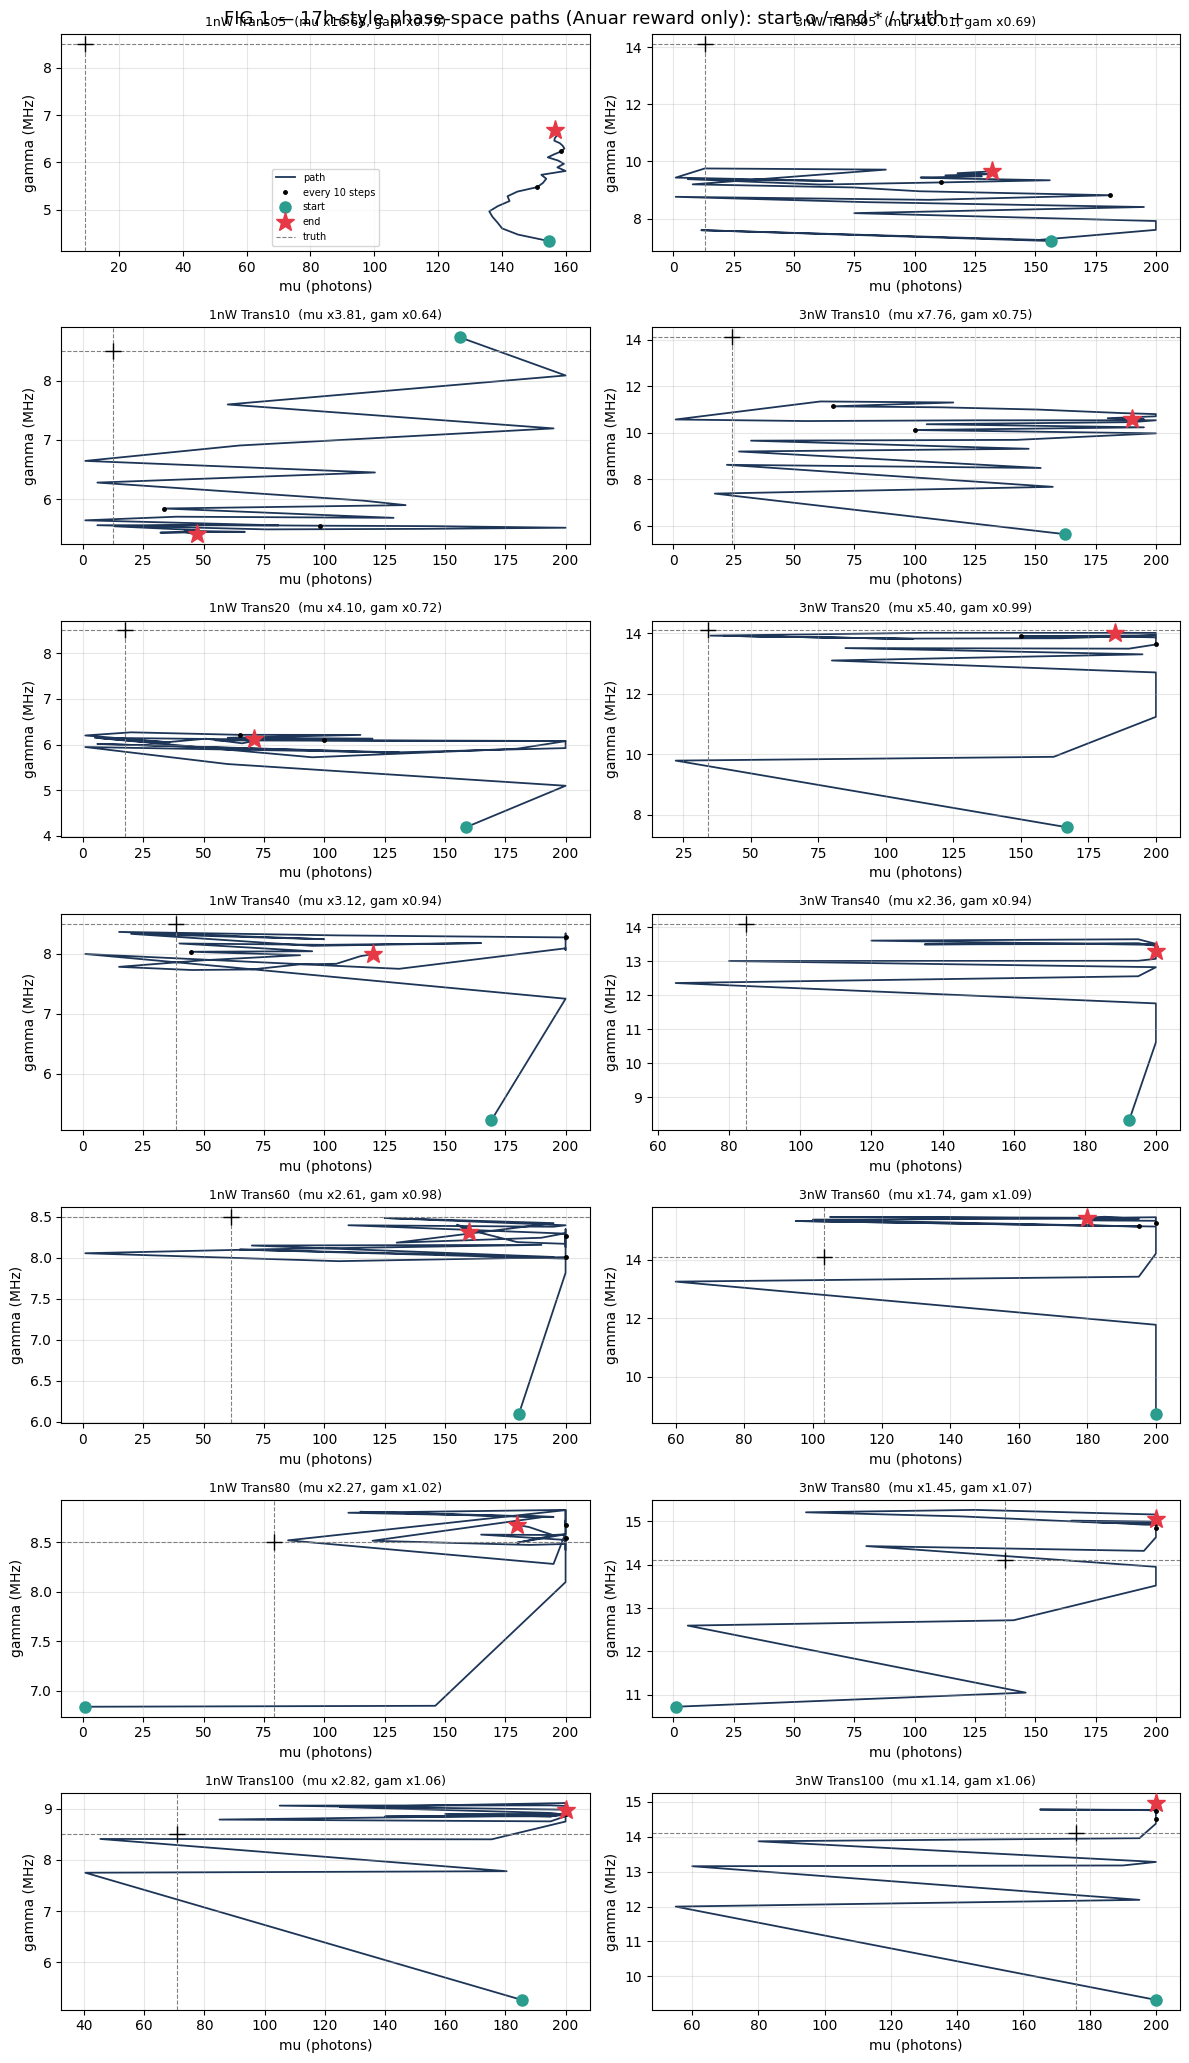

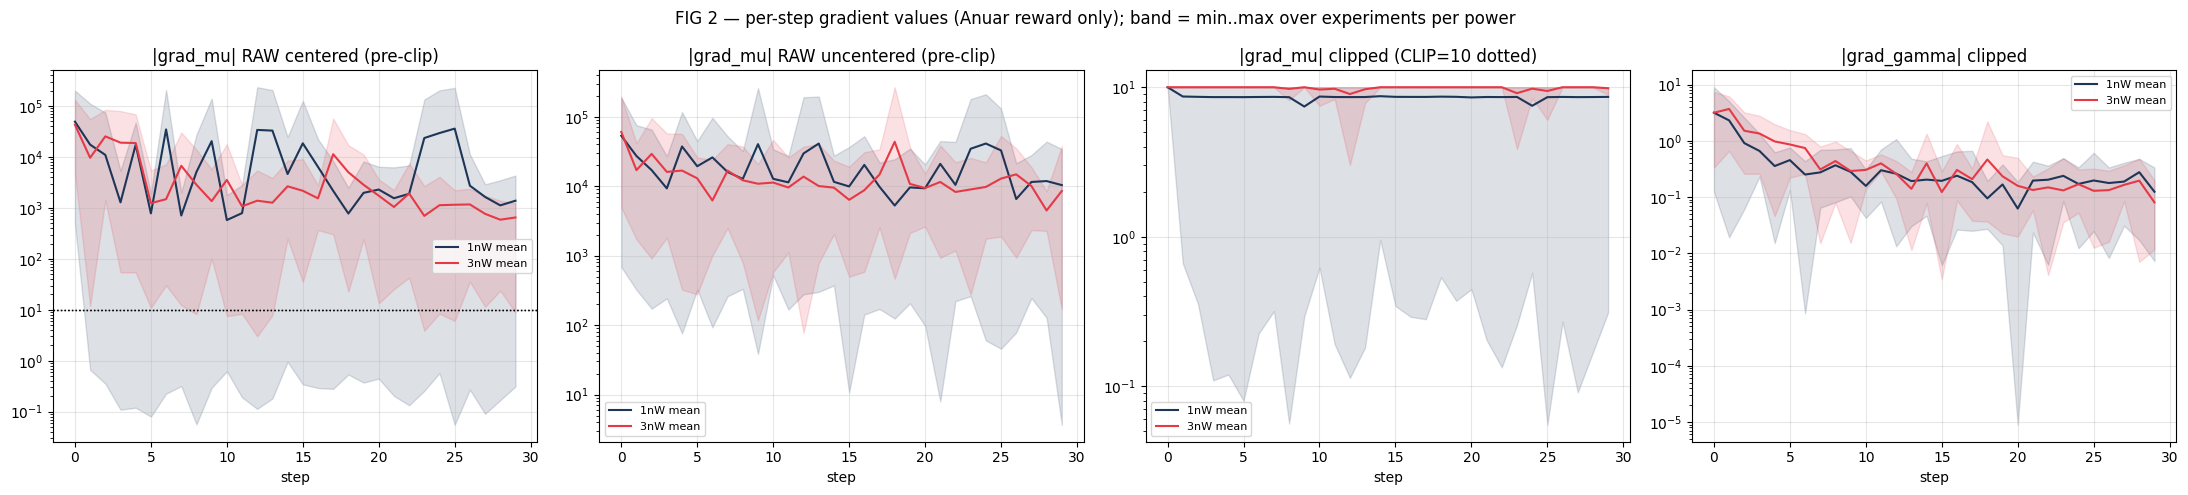

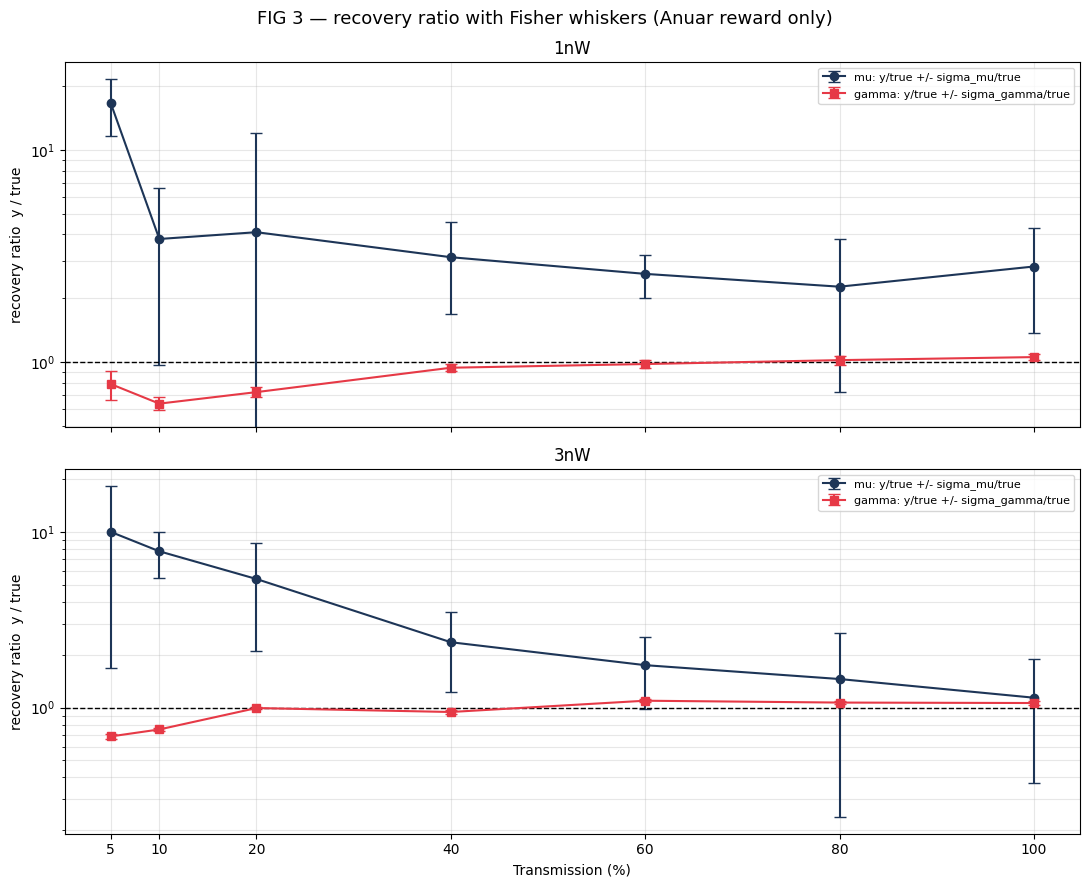

exp           mu_true   mu_fin      x | gam_true  gam_fin      x |    s_mu  s_gam
------------------------------------------------------------------------------------
1nW Trans05      9.39   156.69  16.68 |      8.5     6.69   0.79 |   47.07   1.04
1nW Trans10     12.37    47.12   3.81 |      8.5     5.41   0.64 |   35.12   0.38
1nW Trans20     17.32    71.00   4.10 |      8.5     6.13   0.72 |  137.43   0.32
1nW Trans40     38.41   120.00   3.12 |      8.5     7.99   0.94 |   55.10   0.29
1nW Trans60     61.37   160.00   2.61 |      8.5     8.32   0.98 |   36.35   0.34
1nW Trans80     79.36   180.00   2.27 |      8.5     8.68   1.02 |  122.48   0.42
1nW Trans100    70.82   200.00   2.82 |      8.5     8.97   1.06 |  103.04   0.27
3nW Trans05     13.20   132.21  10.01 |     14.1     9.66   0.69 |  110.03   0.36
3nW Trans10     24.48   190.00   7.76 |     14.1    10.58   0.75 |   55.55   0.26
3nW Trans20     34.28   185.00   5.40 |     14.1    14.01   0.99 |  112.55   0.22
3nW Trans40  

In [7]:
# ============================================================
# FIG 1 — 17h-style phase-space paths (mu, gamma): 2 cols (1nW|3nW) x 7 rows (T)
# ============================================================
Tlist = [5, 10, 20, 40, 60, 80, 100]
by = {(r['power'], r['T']): r for r in results}
fig, axes = plt.subplots(len(Tlist), 2, figsize=(12, 3.0 * len(Tlist)))
for ci, p in enumerate(['1nW', '3nW']):
    for ri, t in enumerate(Tlist):
        ax = axes[ri][ci]
        rr = by.get((p, t))
        if rr is None:
            ax.axis('off'); continue
        h = rr['history']
        mup = [x['mu'] for x in h]; gp = [x['gamma'] for x in h]
        ax.plot(mup, gp, '-', color='#1d3557', lw=1.3, zorder=1)          # path
        ax.plot(mup[::10], gp[::10], 'k.', ms=5, zorder=2)                 # every 10 steps
        ax.plot(mup[0], gp[0], 'o', color='#2a9d8f', ms=8, zorder=3)       # start
        ax.plot(mup[-1], gp[-1], '*', color='#e63946', ms=14, zorder=4)    # end
        ax.axvline(rr['mu_true'], color='gray', ls='--', lw=0.8)
        ax.axhline(rr['gamma_true'], color='gray', ls='--', lw=0.8)
        ax.plot(rr['mu_true'], rr['gamma_true'], 'k+', ms=11, zorder=5)
        ax.set_title(f'{p} Trans{t:02d}  (mu x{rr["mu_final"]/rr["mu_true"]:.2f}, gam x{rr["gamma_final"]/rr["gamma_true"]:.2f})', fontsize=9)
        ax.set_xlabel('mu (photons)'); ax.set_ylabel('gamma (MHz)'); ax.grid(alpha=0.3)
        if ri == 0 and ci == 0:
            ax.legend(['path', 'every 10 steps', 'start', 'end', 'truth'], fontsize=7, loc='best')
plt.suptitle('FIG 1 — 17h-style phase-space paths (Anuar reward only): start o / end * / truth +', fontsize=13)
plt.tight_layout(); plt.show()

# ============================================================
# FIG 2 — gradient values per step: raw |grad_mu|, clipped |grad_mu|, |grad_gamma|
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for p, col in [('1nW', '#1d3557'), ('3nW', '#e63946')]:
    rs = [r for r in results if r['power'] == p]
    if not rs:
        continue
    steps = list(range(N_ITER))
    G_raw = np.array([[h['abs_grad_mu_raw'] for h in r['history']] for r in rs])
    G_rawu = np.array([[h['abs_grad_mu_raw_u'] for h in r['history']] for r in rs])
    G_clip = np.array([[h['abs_grad_mu'] for h in r['history']] for r in rs])
    G_gam = np.array([[h['abs_grad_gamma'] for h in r['history']] for r in rs])
    for ax, G, ttl in [(axes[0], G_raw, '|grad_mu| RAW centered'),
                       (axes[1], G_rawu, '|grad_mu| RAW uncentered (diag)'),
                       (axes[2], G_clip, '|grad_mu| clipped'),
                       (axes[3], G_gam, '|grad_gamma|')]:
        ax.plot(steps, G.mean(0), '-', color=col, label=f'{p} mean')
        ax.fill_between(steps, G.min(0), G.max(0), color=col, alpha=0.15)
    axes[0].axhline(CLIP, color='k', ls=':', lw=1)
for ax, ttl in zip(axes, ['|grad_mu| RAW centered (pre-clip)', '|grad_mu| RAW uncentered (pre-clip)', '|grad_mu| clipped (CLIP=10 dotted)', '|grad_gamma| clipped']):
    ax.set_title(ttl); ax.set_xlabel('step'); ax.set_yscale('log'); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.suptitle('FIG 2 — per-step gradient values (Anuar reward only); band = min..max over experiments per power')
plt.tight_layout(); plt.show()

# ============================================================
# FIG 3 — recovery ratio y/true with Fisher whiskers (mu & gamma hue; 1nW top, 3nW bottom)
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)
for ax, p in zip(axes, ['1nW', '3nW']):
    rs = sorted([r for r in results if r['power'] == p], key=lambda z: z['T'])
    xs = [r['T'] for r in rs]
    mu_ratio = [r['mu_final'] / r['mu_true'] for r in rs]
    mu_err = [r['std_mu'] / r['mu_true'] for r in rs]
    g_ratio = [r['gamma_final'] / r['gamma_true'] for r in rs]
    g_err = [r['std_gamma'] / r['gamma_true'] for r in rs]
    ax.errorbar(xs, mu_ratio, yerr=mu_err, fmt='o-', color='#1d3557', capsize=4, label='mu: y/true +/- sigma_mu/true')
    ax.errorbar(xs, g_ratio, yerr=g_err, fmt='s-', color='#e63946', capsize=4, label='gamma: y/true +/- sigma_gamma/true')
    ax.axhline(1.0, color='k', ls='--', lw=1)
    ax.set_yscale('log'); ax.set_ylabel('recovery ratio  y / true')
    ax.set_title(f'{p}'); ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8)
axes[-1].set_xlabel('Transmission (%)'); axes[-1].set_xticks([5, 10, 20, 40, 60, 80, 100])
plt.suptitle('FIG 3 — recovery ratio with Fisher whiskers (Anuar reward only)', fontsize=13)
plt.tight_layout(); plt.show()

# ============================================================
# TABLE — final values + MSE / STE
# ============================================================
print(f"{'exp':<12} {'mu_true':>8} {'mu_fin':>8} {'x':>6} | {'gam_true':>8} {'gam_fin':>8} {'x':>6} | {'s_mu':>7} {'s_gam':>6}")
print('-' * 84)
for r in results:
    print(f"{r['exp']:<12} {r['mu_true']:>8.2f} {r['mu_final']:>8.2f} {r['mu_final']/r['mu_true']:>6.2f} | "
          f"{r['gamma_true']:>8.1f} {r['gamma_final']:>8.2f} {r['gamma_final']/r['gamma_true']:>6.2f} | "
          f"{r['std_mu']:>7.2f} {r['std_gamma']:>6.2f}")

def mse_stats(err):
    err = np.asarray(err, float); sq = err ** 2
    return sq.mean(), math.sqrt(sq.mean()), err.mean()
rmu = np.array([r['mu_final'] / r['mu_true'] - 1 for r in results])
rg = np.array([r['gamma_final'] / r['gamma_true'] - 1 for r in results])
print('\n=== MSE / STE over the %d experiments ===' % len(results))
for lbl, rel in [('mu', rmu), ('gamma', rg)]:
    mse, rmse, bias = mse_stats(rel)
    print(f'{lbl:>6}: rel-RMSE={rmse*100:6.1f}%  rel-bias={bias*100:+6.1f}%')


## Verdict — sigma_prop score denominator: mild improvement, the runaway persists (prediction only partly holds)

Single change vs 21g: the μ score denominator went from fixed `SIGMA_REF=10` to the per-experiment
`sigma_prop`. All 14 experiments, 100x30, no errors.

**mu — still a runaway, modestly smaller.** `mu_hat/mu_true = 1.14–16.68` (rel-bias +366.3%,
rel-RMSE **550.6%** vs 21g's 770.9%). 4/14 cells pinned exactly at the 200 clamp (1nW T100, 3nW T40,
3nW T80, 3nW T100) vs 5/14 in 21g. So the fix bought ~29% relative reduction but did not stop the
overshoot — mu still lands 1.1–17x above truth.

**The predicted per-cell pattern did NOT hold.** I predicted high-T cells (sigma_prop > 10 -> bigger
denominator -> smaller step) would overshoot less, and low-T cells (sigma_prop < 10) more. Observed: the
high-T cells are essentially *unchanged* (1nW T80/T100 and 3nW T40/T60/T80/T100 identical to 21g:
180/200 and 200/180/200/200), and the cells that moved are low/mid T (1nW T10 189.8 -> 47.1,
1nW T20 200 -> 71.0, 3nW T05 198.6 -> 132.2) — and they moved *down* (less overshoot). Reason: wherever
`|grad_mu_raw|` exceeds `CLIP` the step is `LR x CLIP` regardless of the score denominator, so the
denominator is *inert* there; it only matters in the cells where the raw gradient sits below the clip.

**gamma — untouched.** `gamma_hat/gamma_true = 0.64–1.09`, rel-RMSE 17.8% (21g: 17.1%) — the pathwise
gamma channel is unchanged, as expected; the change is μ-only.

**Takeaway.** Making the score denominator physical (the correct REINFORCE scale, and consistent with the
Fisher) is right and does help — but it is **not sufficient**: with the per-run log-likelihood reward the
step is CLIP-dominated, so the runaway survives. The remaining lever is the *reward scale* itself
(normalise the reward / lower the effective LR / tune the schedules) — which is exactly what the
experiment_5 campaign is set up to search.
